# RheolNet Day 1: 2D Poiseuille PINN Baseline

This notebook builds the Person 1 baseline for RheolNet. It solves a 2D steady Poiseuille flow problem with a physics-informed neural network, validates against the analytical solution, and saves a figure called `validation_day1.png`.

The goal is to confirm that PyTorch autograd, second derivatives, Tanh activations, and the PINN loss pipeline are all working before extending the code to Carreau-Yasuda rheology.

In [10]:
import math
import random
import subprocess
import sys
import os
from dataclasses import dataclass
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

torch.set_default_dtype(torch.float32)

def ensure_p100_ready():
    if not torch.cuda.is_available():
        print('CUDA available: no')
        return False

    gpu_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability(0)
    device_arch = f'sm_{major}{minor}'
    supported_arches = set(torch.cuda.get_arch_list())

    print('CUDA available: yes')
    print(f'GPU name: {gpu_name}')
    print(f'GPU capability: {major}.{minor} ({device_arch})')
    print(f'PyTorch supports: {sorted(supported_arches)}')

    if device_arch not in supported_arches:
        print('Current PyTorch build does not support this GPU.')
        print('Installing a P100-compatible PyTorch wheel...')
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '--upgrade', '--no-cache-dir',
            'torch==2.4.1', 'torchvision==0.19.1', 'torchaudio==2.4.1'
        ], check=True)
        print('Restart the Kaggle kernel now, then rerun Cell 1.')
        raise SystemExit

    return True

cuda_ready = ensure_p100_ready()
device = torch.device('cuda' if cuda_ready else 'cpu')
print('Using device:', device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

CUDA available: yes
GPU name: Tesla P100-PCIE-16GB
GPU capability: 6.0 (sm_60)
PyTorch supports: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
Using device: cuda


## Problem setup

This baseline is trained on synthetic data only: interior collocation points sampled from the PDE domain, boundary points enforcing no-slip and pressure conditions, and the analytic Poiseuille solution used as supervision at the boundaries and for validation.

We solve a manufactured 2D steady Poiseuille solution in the unit square $x \in [0,1]$, $y \in [0,1]$. The exact solution is:

$$
u(x,y) = 4y(1-y), \quad v(x,y) = 0, \quad p(x,y) = -8x.
$$

With viscosity $\nu = 1$, this satisfies the steady incompressible Navier-Stokes equations in the low-Reynolds-number limit. This is a clean baseline for testing the PINN pipeline before moving to Carreau-Yasuda rheology.

In [11]:
@dataclass
class Config:
    n_collocation: int = 1024
    n_boundary: int = 256
    n_train_steps: int = 2000
    learning_rate: float = 1e-3
    hidden_layers: int = 4
    hidden_width: int = 64
    viscosity: float = 1.0

cfg = Config()

def exact_solution(xy):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    u = 4.0 * y * (1.0 - y)
    v = torch.zeros_like(u)
    p = -8.0 * x
    return u, v, p

def sample_interior(n):
    xy = torch.rand(n, 2, device=device)
    xy.requires_grad_(True)
    return xy

def sample_boundary(n):
    n_side = n // 4
    y = torch.rand(n_side, 1, device=device)
    x = torch.rand(n_side, 1, device=device)

    bottom = torch.cat([x, torch.zeros_like(x)], dim=1)
    top = torch.cat([x, torch.ones_like(x)], dim=1)
    left = torch.cat([torch.zeros_like(y), y], dim=1)
    right = torch.cat([torch.ones_like(y), y], dim=1)

    boundary = torch.cat([bottom, top, left, right], dim=0)
    boundary.requires_grad_(True)
    return boundary

In [12]:
class PINN(nn.Module):
    def __init__(self, in_dim=2, out_dim=3, hidden_layers=4, hidden_width=64):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_width), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.extend([nn.Linear(hidden_width, hidden_width), nn.Tanh()])
        layers.append(nn.Linear(hidden_width, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = PINN(hidden_layers=cfg.hidden_layers, hidden_width=cfg.hidden_width).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
mse = nn.MSELoss()

def gradients(outputs, inputs):
    return torch.autograd.grad(
        outputs=outputs,
        inputs=inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

def pde_residuals(xy):
    pred = model(xy)
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]

    grad_u = gradients(u, xy)
    grad_v = gradients(v, xy)
    grad_p = gradients(p, xy)

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]
    v_x = grad_v[:, 0:1]
    v_y = grad_v[:, 1:2]
    p_x = grad_p[:, 0:1]
    p_y = grad_p[:, 1:2]

    u_xx = gradients(u_x, xy)[:, 0:1]
    u_yy = gradients(u_y, xy)[:, 1:2]
    v_xx = gradients(v_x, xy)[:, 0:1]
    v_yy = gradients(v_y, xy)[:, 1:2]

    continuity = u_x + v_y
    momentum_x = u * u_x + v * u_y + p_x - cfg.viscosity * (u_xx + u_yy)
    momentum_y = u * v_x + v * v_y + p_y - cfg.viscosity * (v_xx + v_yy)
    return continuity, momentum_x, momentum_y

In [13]:
CHECKPOINT_DIR = '/kaggle/working/day1_checkpoints'
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'day1_checkpoint.pt')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def get_rng_state():
    state = {
        'python_random': random.getstate(),
        'numpy_random': np.random.get_state(),
        'torch_random': torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state['torch_cuda_random'] = torch.cuda.get_rng_state_all()
    return state


def set_rng_state(state):
    random.setstate(state['python_random'])
    np.random.set_state(state['numpy_random'])
    torch.set_rng_state(state['torch_random'])
    if torch.cuda.is_available() and 'torch_cuda_random' in state:
        torch.cuda.set_rng_state_all(state['torch_cuda_random'])


def save_checkpoint(path, step, model, optimizer, history):
    payload = {
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'rng_state': get_rng_state(),
        'cfg': cfg.__dict__,
    }
    torch.save(payload, path)
    print(f'Saved checkpoint to {path} at step {step}')


def load_checkpoint(path, model, optimizer):
    if not os.path.exists(path):
        return 0, {'total': [], 'physics': [], 'boundary': []}

    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'rng_state' in checkpoint:
        set_rng_state(checkpoint['rng_state'])

    loaded_history = checkpoint.get('history', {'total': [], 'physics': [], 'boundary': []})
    loaded_step = int(checkpoint.get('step', 0))
    print(f'Loaded checkpoint from {path} at step {loaded_step}')
    return loaded_step, loaded_history


start_step, history = load_checkpoint(CHECKPOINT_PATH, model, optimizer)
print('Resume step:', start_step)

Resume step: 0


In [14]:
if 'model' not in globals() or 'history' not in globals():
    raise RuntimeError('Run the model definition, checkpoint, and setup cells above before training.')

history = history if 'history' in globals() else {
    'total': [],
    'physics': [],
    'boundary': [],
}

save_every = 250

total_start = start_step + 1 if 'start_step' in globals() else 1

for step in range(total_start, cfg.n_train_steps + 1):
    optimizer.zero_grad()

    xy_f = sample_interior(cfg.n_collocation)
    xy_b = sample_boundary(cfg.n_boundary)

    continuity, momentum_x, momentum_y = pde_residuals(xy_f)
    physics_loss = mse(continuity, torch.zeros_like(continuity)) + mse(momentum_x, torch.zeros_like(momentum_x)) + mse(momentum_y, torch.zeros_like(momentum_y))

    pred_b = model(xy_b)
    u_b, v_b, p_b = pred_b[:, 0:1], pred_b[:, 1:2], pred_b[:, 2:3]
    u_true_b, v_true_b, p_true_b = exact_solution(xy_b)
    boundary_loss = mse(u_b, u_true_b) + mse(v_b, v_true_b) + mse(p_b, p_true_b)

    total_loss = physics_loss + 10.0 * boundary_loss
    total_loss.backward()
    optimizer.step()

    history['total'].append(total_loss.item())
    history['physics'].append(physics_loss.item())
    history['boundary'].append(boundary_loss.item())

    if step % 500 == 0 or step == 1 or step == cfg.n_train_steps:
        print(f'Step {step:5d} | total={total_loss.item():.4e} | physics={physics_loss.item():.4e} | boundary={boundary_loss.item():.4e}')

    if step % save_every == 0 or step == cfg.n_train_steps:
        save_checkpoint(CHECKPOINT_PATH, step, model, optimizer, history)

Step     1 | total=2.9770e+02 | physics=3.4650e-03 | boundary=2.9770e+01
Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 250
Step   500 | total=7.8013e-02 | physics=3.8814e-02 | boundary=3.9199e-03
Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 500
Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 750
Step  1000 | total=1.8319e-02 | physics=9.2724e-03 | boundary=9.0462e-04
Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 1000
Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 1250
Step  1500 | total=6.3623e-03 | physics=3.3564e-03 | boundary=3.0058e-04
Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 1500
Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 1750
Step  2000 | total=2.9015e-03 | physics=1.5416e-03 | boundary=1.3599e-04
Saved checkpoint to /kaggle/working/day1_ch

u relative L2 error: 0.003706
p relative L2 error: 0.003854


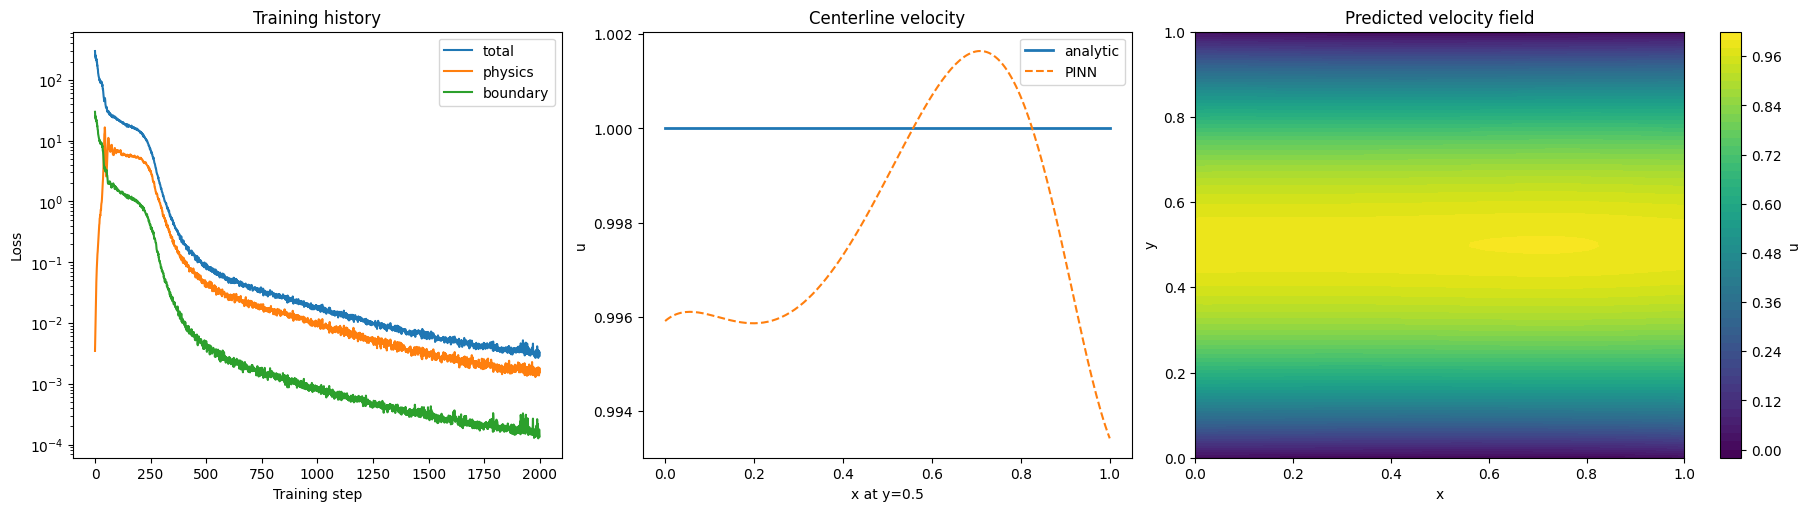

In [15]:
if 'model' not in globals() or 'history' not in globals():
    raise RuntimeError('Run the model definition and training cells above before the validation cell.')

model.eval()

nx, ny = 120, 120
x = torch.linspace(0.0, 1.0, nx, device=device)
y = torch.linspace(0.0, 1.0, ny, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')
xy_grid = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

with torch.no_grad():
    pred_grid = model(xy_grid)
    u_pred = pred_grid[:, 0].reshape(nx, ny).cpu().numpy()
    v_pred = pred_grid[:, 1].reshape(nx, ny).cpu().numpy()
    p_pred = pred_grid[:, 2].reshape(nx, ny).cpu().numpy()

u_true, v_true, p_true = exact_solution(xy_grid)
u_true = u_true.detach().reshape(nx, ny).cpu().numpy()
v_true = v_true.detach().reshape(nx, ny).cpu().numpy()
p_true = p_true.detach().reshape(nx, ny).cpu().numpy()

u_error_l2 = np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)
p_error_l2 = np.linalg.norm(p_pred - p_true) / np.linalg.norm(p_true)
print(f'u relative L2 error: {u_error_l2:.6f}')
print(f'p relative L2 error: {p_error_l2:.6f}')

centerline = torch.stack([torch.linspace(0.0, 1.0, 200, device=device), 0.5 * torch.ones(200, device=device)], dim=1)
with torch.no_grad():
    center_pred = model(centerline)[:, 0].cpu().numpy()
    center_true = exact_solution(centerline)[0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

loss_ax = axes[0]
loss_ax.semilogy(history['total'], label='total')
loss_ax.semilogy(history['physics'], label='physics')
loss_ax.semilogy(history['boundary'], label='boundary')
loss_ax.set_xlabel('Training step')
loss_ax.set_ylabel('Loss')
loss_ax.set_title('Training history')
loss_ax.legend()

profile_ax = axes[1]
profile_ax.plot(np.linspace(0.0, 1.0, 200), center_true, label='analytic', linewidth=2)
profile_ax.plot(np.linspace(0.0, 1.0, 200), center_pred, '--', label='PINN')
profile_ax.set_xlabel('x at y=0.5')
profile_ax.set_ylabel('u')
profile_ax.set_title('Centerline velocity')
profile_ax.legend()

field_ax = axes[2]
contour = field_ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), u_pred, levels=50, cmap='viridis')
fig.colorbar(contour, ax=field_ax, label='u')
field_ax.set_xlabel('x')
field_ax.set_ylabel('y')
field_ax.set_title('Predicted velocity field')

plt.savefig('validation_day1.png', dpi=200, bbox_inches='tight')
plt.show()

## Task 1.1
Cell 7:from physics.navier_stokes import compute_ns_residuals_nonnewtonian

Cell 8: run it, plot viscosity profile across channel

viscosity_day2.png output ← our deliverable

In [16]:
def carreau_yasuda_viscosity(gamma_dot, eta0=0.056, eta_inf=0.0035, lam=3.313, n=0.3568, a=2.0):
    """
    Carreau-Yasuda model for blood viscosity.
    
    eta0    = 0.056  Pa·s  — thick blood at rest (RBCs clumped)
    eta_inf = 0.0035 Pa·s  — thin blood at high speed (RBCs dispersed)
    lam     = 3.313  s     — time constant: where thinning kicks in
    n       = 0.3568       — how steep the thinning is (< 1 = shear-thinning)
    a       = 2.0          — shape of the thinning curve
    
    gamma_dot: shear rate tensor |du/dy|, shape [N]
    returns: viscosity tensor, same shape [N]
    """
    return eta_inf + (eta0 - eta_inf) * (1.0 + (lam * gamma_dot) ** a) ** ((n - 1.0) / a)

In [17]:
def compute_ns_residuals_nonnewtonian(xy, eta0=0.056, eta_inf=0.0035, lam=3.313, n=0.3568, a=2.0):
    """
    Non-Newtonian NS residuals using Carreau-Yasuda viscosity.
    
    Our model takes xy as [N,2] and outputs [N,3] = (u, v, p).
    This function is written to match that interface.
    
    xy: [N, 2] tensor with requires_grad=True already set
    returns: R_momentum_x, R_continuity, eta_field, gamma_dot_field
    """
    xy = xy.detach().requires_grad_(True)
    
    pred = model(xy)
    u = pred[:, 0:1]   # x-velocity, shape [N, 1]
    v = pred[:, 1:2]   # y-velocity, shape [N, 1]
    p = pred[:, 2:3]   # pressure,   shape [N, 1]

    def grad(f, wrt):
        return torch.autograd.grad(
            f, wrt,
            grad_outputs=torch.ones_like(f),
            create_graph=True,
            retain_graph=True
        )[0]

    # First derivatives
    grad_u = grad(u, xy)          # [N, 2]: columns are du/dx, du/dy
    grad_p = grad(p, xy)          # [N, 2]: columns are dp/dx, dp/dy

    du_dx = grad_u[:, 0:1]        # [N, 1]
    du_dy = grad_u[:, 1:2]        # [N, 1]  ← this is what drives shear rate
    dp_dx = grad_p[:, 0:1]        # [N, 1]

    # Shear rate: how fast velocity changes across the pipe
    # Add 1e-8 to avoid exactly zero (causes numerical issues in CY formula)
    gamma_dot = torch.abs(du_dy) + 1e-8    # [N, 1]

    # Local viscosity at every point via Carreau-Yasuda
    eta = carreau_yasuda_viscosity(gamma_dot, eta0, eta_inf, lam, n, a)  # [N, 1]

    # Viscous stress = eta * du/dy  (force one fluid layer exerts on neighbour)
    stress = eta * du_dy                   # [N, 1]

    # d/dy(eta * du/dy) — net viscous force per unit volume
    # autograd applies product rule automatically here
    d_stress_dy = grad(stress, xy)[:, 1:2] # [N, 1]

    # Momentum residual: pressure force + viscous force = 0
    R_momentum = -dp_dx + d_stress_dy      # [N, 1]

    # Continuity: fully-developed flow → du/dx = 0
    R_continuity = du_dx                   # [N, 1]

    # Return flat [N] tensors so they're easy to work with
    return (R_momentum.squeeze(),
            R_continuity.squeeze(),
            eta.squeeze(),
            gamma_dot.squeeze())

=== Sanity check ===
  Centreline (y=0.5): eta = 0.05592 Pa·s
  Bottom wall (y=0):  eta = 0.01340 Pa·s
  Top wall    (y=1):  eta = 0.01339 Pa·s
  Max shear rate: 4.0345 1/s
  Min shear rate: 1.8789e-02 1/s
  ✓ Shear-thinning confirmed — centreline thicker than wall


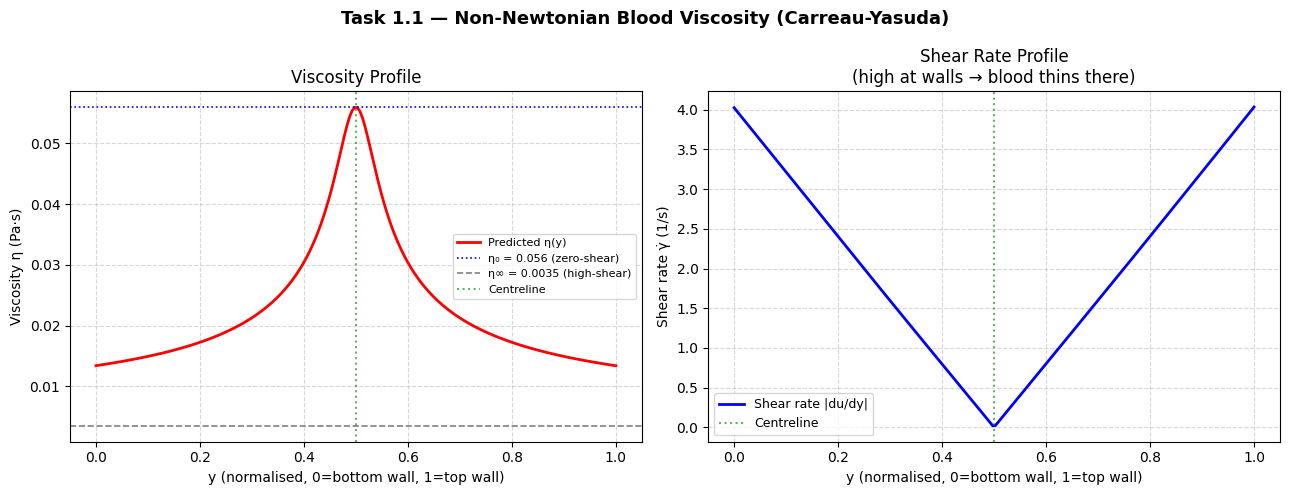

Saved: viscosity_day2.png


In [18]:
model.eval()

# Sample a cross-section across the pipe at x = 0.5 (midpoint of unit domain)
# y goes from 0 (bottom wall) to 1 (top wall) — matches your notebook's coordinate system
n_pts = 200
y_vals = torch.linspace(0.0, 1.0, n_pts, device=device)
x_vals = torch.full((n_pts,), 0.5, device=device)
xy_slice = torch.stack([x_vals, y_vals], dim=1)   # [200, 2]

# Run the non-Newtonian residuals
_, _, eta_field, gamma_dot_field = compute_ns_residuals_nonnewtonian(xy_slice)

# Pull off GPU and out of PyTorch computation graph for plotting
y_np         = y_vals.detach().cpu().numpy()
eta_np       = eta_field.detach().cpu().numpy()
gamma_dot_np = gamma_dot_field.detach().cpu().numpy()

# Sanity check before plotting
print("=== Sanity check ===")
print(f"  Centreline (y=0.5): eta = {eta_np[n_pts//2]:.5f} Pa·s")
print(f"  Bottom wall (y=0):  eta = {eta_np[0]:.5f} Pa·s")
print(f"  Top wall    (y=1):  eta = {eta_np[-1]:.5f} Pa·s")
print(f"  Max shear rate: {gamma_dot_np.max():.4f} 1/s")
print(f"  Min shear rate: {gamma_dot_np.min():.4e} 1/s")

if eta_np[n_pts//2] > eta_np[0]:
    print("  ✓ Shear-thinning confirmed — centreline thicker than wall")
else:
    print("  ✗ WARNING: viscosity pattern inverted — model may not be converged yet")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 1.1 — Non-Newtonian Blood Viscosity (Carreau-Yasuda)", fontsize=13, fontweight='bold')

# Left: viscosity across the pipe
ax1 = axes[0]
ax1.plot(y_np, eta_np, 'r-', linewidth=2, label='Predicted η(y)')
ax1.axhline(0.056,  color='blue', linestyle=':', linewidth=1.2, label='η₀ = 0.056 (zero-shear)')
ax1.axhline(0.0035, color='gray', linestyle='--', linewidth=1.2, label='η∞ = 0.0035 (high-shear)')
ax1.axvline(0.5, color='green', linestyle=':', alpha=0.6, label='Centreline')
ax1.set_xlabel('y (normalised, 0=bottom wall, 1=top wall)')
ax1.set_ylabel('Viscosity η (Pa·s)')
ax1.set_title('Viscosity Profile')
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.5)

# Right: shear rate (explains why viscosity looks the way it does)
ax2 = axes[1]
ax2.plot(y_np, gamma_dot_np, 'b-', linewidth=2, label='Shear rate |du/dy|')
ax2.axvline(0.5, color='green', linestyle=':', alpha=0.6, label='Centreline')
ax2.set_xlabel('y (normalised, 0=bottom wall, 1=top wall)')
ax2.set_ylabel('Shear rate γ̇ (1/s)')
ax2.set_title('Shear Rate Profile\n(high at walls → blood thins there)')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('viscosity_day2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viscosity_day2.png")

In [21]:
# Save the model checkpoint again (preserves trained state for future use)
save_checkpoint(CHECKPOINT_PATH, cfg.n_train_steps, model, optimizer, history)

Saved checkpoint to /kaggle/working/day1_checkpoints/day1_checkpoint.pt at step 2000


In [22]:
import os
checkpoint_size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024**2)
checkpoint_time = os.path.getmtime(CHECKPOINT_PATH)
from datetime import datetime
timestamp = datetime.fromtimestamp(checkpoint_time).strftime('%Y-%m-%d %H:%M:%S')

print(f"Checkpoint saved at: {timestamp}")
print(f"File size: {checkpoint_size_mb:.2f} MB")
print(f"Path: {CHECKPOINT_PATH}")

Checkpoint saved at: 2026-08-05 05:23:51
File size: 0.22 MB
Path: /kaggle/working/day1_checkpoints/day1_checkpoint.pt
